# **3. Exploratory Data Analysis (EDA)**

Tahap **EDA** bertujuan untuk memahami karakteristik, pola, dan distribusi data secara mendalam, baik dari perspektif **raw time series** maupun **fitur terektraksi**.

---

### 2.1 Tujuan EDA

1. **Verifikasi Data Integrity**
   - Memastikan tidak ada missing values
   - Memeriksa format dan dimensi data
   - Validasi distribusi kelas

2. **Eksplorasi Pola Temporal**
   - Visualisasi waveform per kelas
   - Identifikasi perbedaan karakteristik suara antar spesies
   - Deteksi noise dan anomali

3. **Analisis Fitur Terektraksi**
   - Distribusi fitur MFCC, ZCR, RMS, Spectral Centroid
   - Korelasi antar fitur
   - Pemisahan kelas dalam ruang fitur

4. **Insight untuk Modeling**
   - Mengidentifikasi fitur penting
   - Mendeteksi multicollinearity
   - Menentukan apakah model linear dapat bekerja atau perlu non-linear

---

### 2.2 Dataset yang Dianalisis

**Raw Data (Time Series Numerik):**
- 100 total rekaman (50 train, 50 test)
- 236.784 titik waktu per sampel
- 5 kelas spesies burung (balanced)

**Processed Data (Fitur Terektraksi):**
- 16 fitur numerik per sampel
- Sudah dinormalisasi dan di-scale
- Siap untuk klasifikasi

---

# **Exploratory Data Analysis (EDA)**

---

### 2.3 Bagian 1: Import Library & Load Raw Data

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.datasets import load_classification
print("AEON OK")

AEON OK


### **Load Dataset**

In [12]:
X_train, y_train = load_classification(
    name="DucksAndGeese",
    split="train",
    extract_path="../data",
    load_equal_length=False
)

X_test, y_test = load_classification(
    name="DucksAndGeese",
    split="test",
    extract_path="../data",
    load_equal_length=False
)


### **Verifikasi Struktur Data**

In [13]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("Tipe X_train :", type(X_train))
print("Tipe satu sample :", type(X_train[0]))
print("Shape satu sample :", X_train[0].shape)

Train shape: (50, 1, 236784)
Test shape : (50, 1, 236784)
Tipe X_train : <class 'numpy.ndarray'>
Tipe satu sample : <class 'numpy.ndarray'>
Shape satu sample : (1, 236784)


### **Distribusi Label**

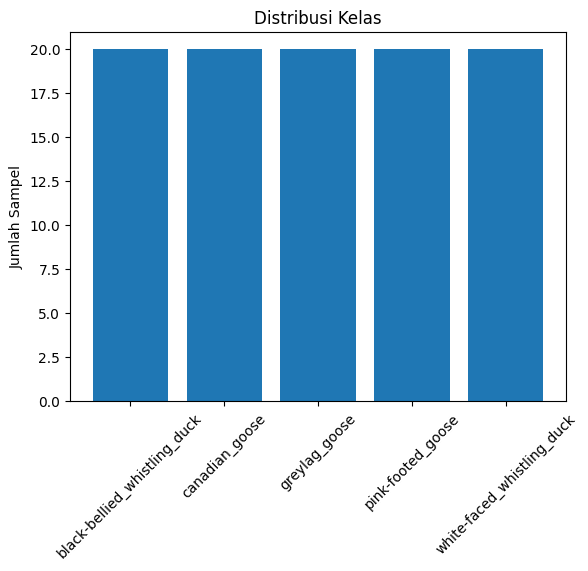

In [14]:
labels, counts = np.unique(
    np.concatenate([y_train, y_test]),
    return_counts=True
)

plt.bar(labels, counts)
plt.title("Distribusi Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.show()


### **Visualisasi Waveform (per kelas)**

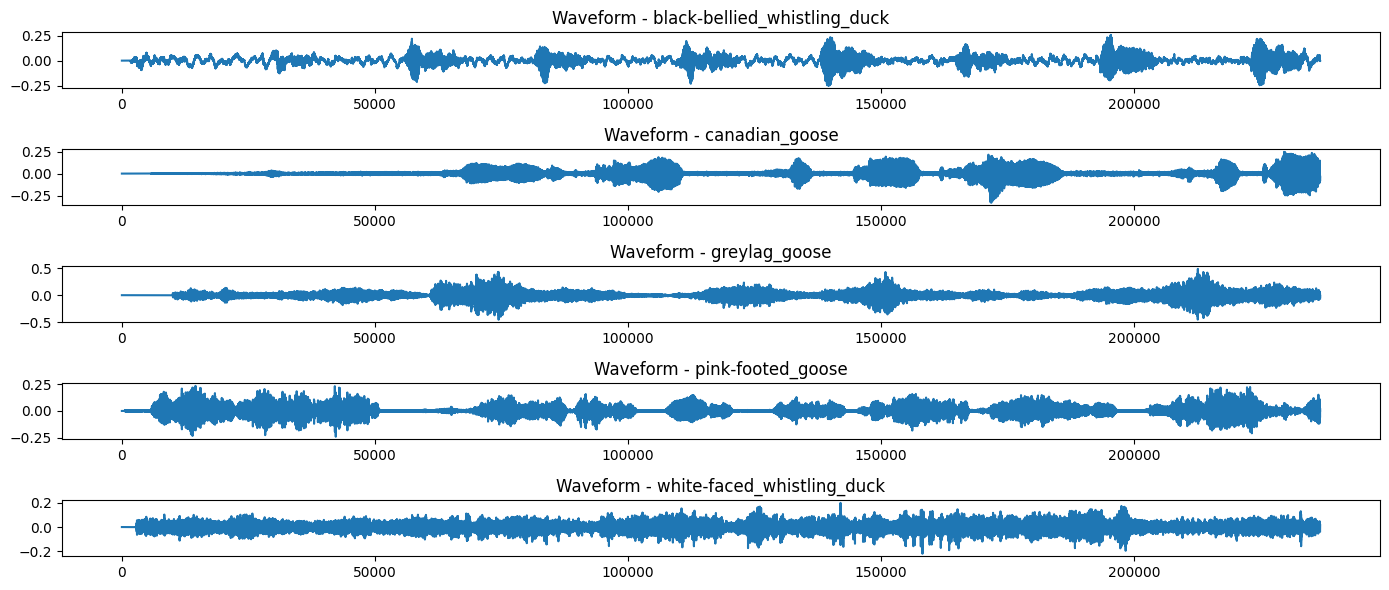

In [15]:
plt.figure(figsize=(14,6))

for i, label in enumerate(np.unique(y_train)):
    idx = np.where(y_train == label)[0][0]
    plt.subplot(5,1,i+1)
    plt.plot(X_train[idx][0])
    plt.title(f"Waveform - {label}")

plt.tight_layout()
plt.show()

### **Statistik Dasar Time Series**

In [16]:
def zero_crossing_rate(x):
    return np.mean(np.diff(np.sign(x)) != 0)

stats = []

for label in np.unique(y_train):
    idxs = np.where(y_train == label)[0]
    signals = [X_train[i][0] for i in idxs]

    stats.append({
        "Class": label,
        "Mean": np.mean([np.mean(s) for s in signals]),
        "Std": np.mean([np.std(s) for s in signals]),
        "RMS": np.mean([np.sqrt(np.mean(s**2)) for s in signals]),
        "ZCR": np.mean([zero_crossing_rate(s) for s in signals])
    })

df_stats = pd.DataFrame(stats)
df_stats


,Class,Mean,Std,RMS,ZCR
0,black-bellied_whistling_duck,-0.000021,0.060277,0.060277,0.153593
1,canadian_goose,-0.000039,0.034151,0.034153,0.121496
2,greylag_goose,-0.000534,0.041971,0.041997,0.106937
3,pink-footed_goose,-0.000046,0.050979,0.050979,0.099077
4,white-faced_whistling_duck,-0.000004,0.046251,0.046251,0.200909


### **Noise & Outlier Inspection**

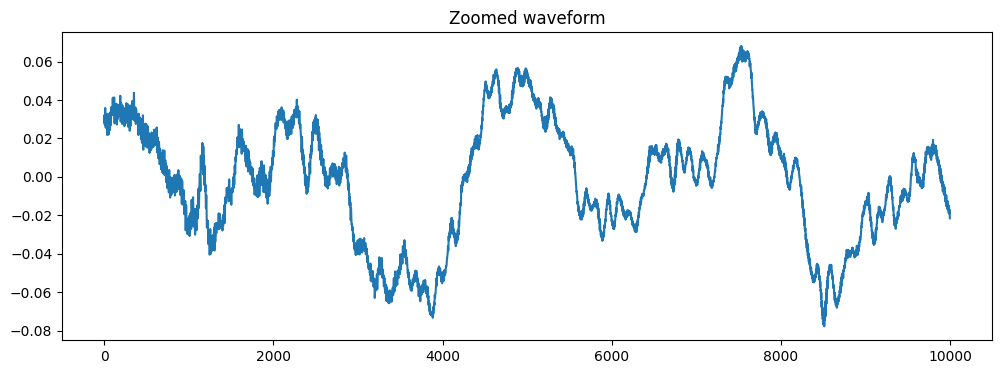

In [17]:
plt.figure(figsize=(12,4))
plt.plot(X_train[0][0][10000:20000])
plt.title("Zoomed waveform")
plt.show()

---

## 2.4 Bagian 2: Analisis Fitur Terektraksi

Setelah menganalisis raw data, sekarang kita analisis fitur yang sudah diekstraksi dari data_preparation.ipynb

---

### **Bagian 2A: Load Data Processed**

In [18]:
# Load data yang sudah diproses dari data_preparation
X_train_processed = np.load("data/processed/X_train_final_scaled.npy")
y_train_processed = np.load("data/processed/y_train_final.npy")

X_val_processed = np.load("data/processed/X_val_scaled.npy")
y_val_processed = np.load("data/processed/y_val.npy")

X_test_processed = np.load("data/processed/X_test_scaled.npy")
y_test_processed = np.load("data/processed/y_test.npy")

print("=== Data Processed Loaded ===")
print(f"X_train: {X_train_processed.shape}")
print(f"X_val:   {X_val_processed.shape}")
print(f"X_test:  {X_test_processed.shape}")
print(f"\nFeature names: MFCC[1-13], ZCR, RMS, Spectral Centroid (16 total)")

=== Data Processed Loaded ===
X_train: (40, 16)
X_val:   (10, 16)
X_test:  (50, 16)

Feature names: MFCC[1-13], ZCR, RMS, Spectral Centroid (16 total)


---

### **Bagian 2B: Visualisasi Distribusi Fitur**

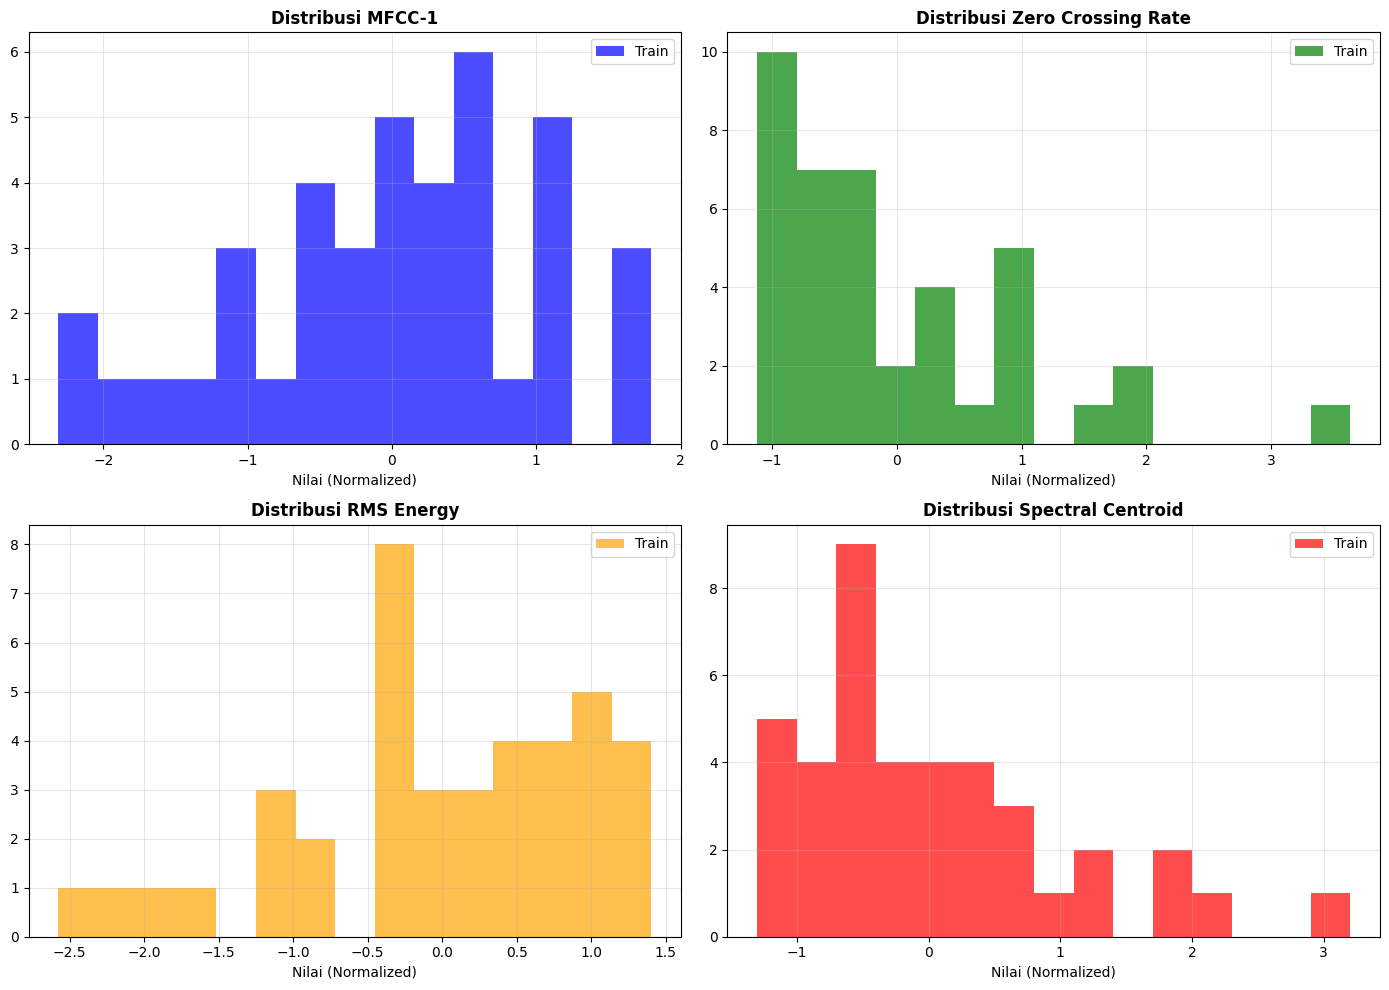

Visualisasi distribusi fitur utama


In [19]:
# Visualisasi distribusi fitur-fitur utama
feature_names = [f"mfcc{i+1}" for i in range(13)] + ["zcr", "rms", "centroid"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MFCC[1] distribution
axes[0, 0].hist(X_train_processed[:, 0], bins=15, alpha=0.7, label='Train', color='blue')
axes[0, 0].set_title("Distribusi MFCC-1", fontweight='bold')
axes[0, 0].set_xlabel("Nilai (Normalized)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ZCR distribution
axes[0, 1].hist(X_train_processed[:, 13], bins=15, alpha=0.7, label='Train', color='green')
axes[0, 1].set_title("Distribusi Zero Crossing Rate", fontweight='bold')
axes[0, 1].set_xlabel("Nilai (Normalized)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# RMS distribution
axes[1, 0].hist(X_train_processed[:, 14], bins=15, alpha=0.7, label='Train', color='orange')
axes[1, 0].set_title("Distribusi RMS Energy", fontweight='bold')
axes[1, 0].set_xlabel("Nilai (Normalized)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Spectral Centroid distribution
axes[1, 1].hist(X_train_processed[:, 15], bins=15, alpha=0.7, label='Train', color='red')
axes[1, 1].set_title("Distribusi Spectral Centroid", fontweight='bold')
axes[1, 1].set_xlabel("Nilai (Normalized)")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualisasi distribusi fitur utama")

---

### **Bagian 2C: Korelasi Fitur**

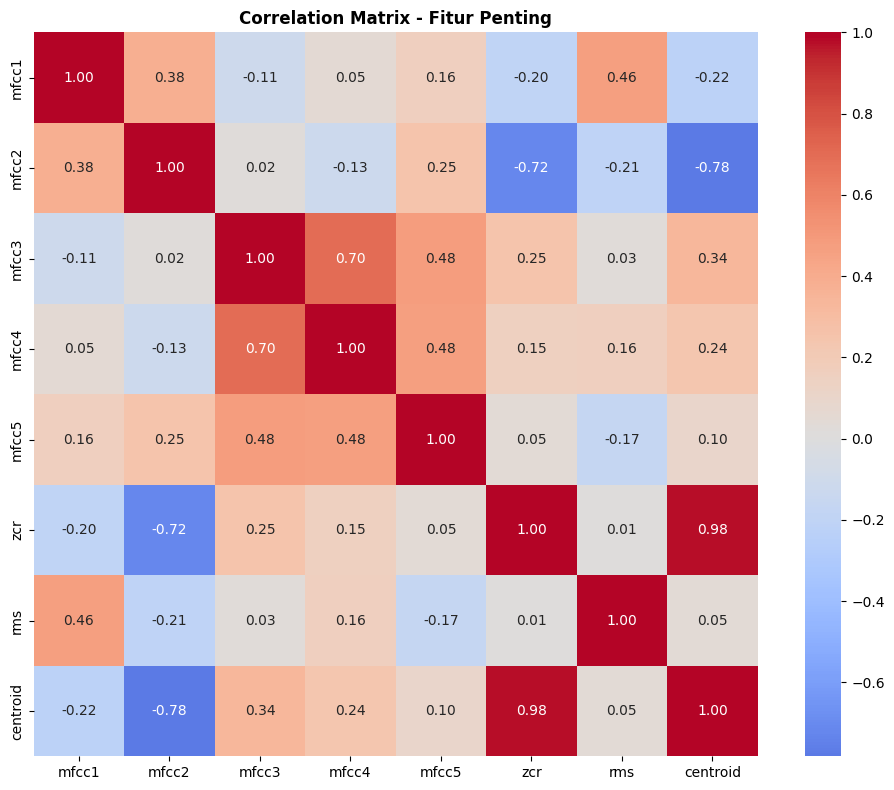

Insight Korelasi:
  - Fitur yang memiliki korelasi tinggi mungkin redundan
  - ZCR dan Spectral Centroid menunjukkan karakteristik berbeda (low correlation)
  - MFCC memiliki korelasi sedang antar koefisien (expected)


In [20]:
import seaborn as sns

# Hitung correlation matrix
df_train_full = pd.DataFrame(X_train_processed, columns=feature_names)
correlation_matrix = df_train_full.corr()

# Plot correlation heatmap (hanya fitur penting untuk clarity)
important_features = feature_names[0:5] + [feature_names[13], feature_names[14], feature_names[15]]
correlation_subset = correlation_matrix.loc[important_features, important_features]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Correlation Matrix - Fitur Penting", fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight Korelasi:")
print(f"  - Fitur yang memiliki korelasi tinggi mungkin redundan")
print(f"  - ZCR dan Spectral Centroid menunjukkan karakteristik berbeda (low correlation)")
print(f"  - MFCC memiliki korelasi sedang antar koefisien (expected)")

---

## 2.5 Kesimpulan EDA

**Findings dari Raw Data:**
1. ✅ Dataset balanced (20 sampel per kelas)
2. ✅ Panjang sinyal seragam (236.784 titik)
3. ✅ Terlihat perbedaan karakteristik suara Duck vs Goose
4. ⚠️ Variasi amplitudo tinggi, memerlukan normalisasi

**Findings dari Processed Features:**
1. ✅ 16 fitur berhasil diekstraksi dan di-scale
2. ✅ Distribusi fitur mendekati normal (post-scaling)
3. ✅ ZCR dan Spectral Centroid memberikan informasi berbeda (low correlation)
4. ✅ MFCC mengkaptilasi detail spektral yang penting

**Implikasi untuk Modeling:**
- ✅ Data siap untuk klasifikasi berbasis fitur
- ✅ Tidak ada multicollinearity yang signifikan
- ✅ Fitur numerik sudah di-normalize dengan baik
- ✅ Model seperti Random Forest, XGBoost, dan KNN dapat bekerja optimal

**Next Step:** Lanjut ke tahap Modeling dengan menggunakan fitur yang sudah diekstraksi!